# Lab 2: Multiple linear regression from scratch

Clean -> covariance/correlation -> split -> scale -> add ones -> fit -> compare.
The calculations use NumPy and pandas. The final plotting cell uses matplotlib.
Keep the intercept column and use the same training mean/std for test data.

In [1]:
import numpy as np
import pandas as pd


## 1. Load

In [2]:
df = pd.read_excel("car_fuel_efficiency_multiple_linear_regression.xlsx")
df = df.apply(pd.to_numeric, errors="coerce").drop_duplicates().dropna()
FEATURES = ["Engine_CC", "Weight_kg", "Horsepower"]
TARGET = "Mileage_kmpl"
X = df[FEATURES].to_numpy(float)
y = df[TARGET].to_numpy(float)
df


,Engine_CC,Weight_kg,Horsepower,Mileage_kmpl
0,800,780,48,24
1,1000,850,60,22
2,1200,900,72,20
3,1400,980,84,18
4,1600,1050,98,16
5,1800,1120,110,15
6,2000,1180,125,14
7,2200,1260,140,13
8,2400,1350,152,12
9,2600,1450,165,11


## 2. Covariance & correlation (from scratch)

In [3]:
A = df[FEATURES + [TARGET]].to_numpy(float)
Ac = A - A.mean(0)
cov = Ac.T @ Ac / (len(A) - 1)
sd = np.sqrt(np.diag(cov))
corr = cov / np.outer(sd, sd)
print("Column order:", FEATURES + [TARGET])
print("Covariance:\n", cov.round(3))
print("Correlation:\n", corr.round(3))


Column order: ['Engine_CC', 'Weight_kg', 'Horsepower', 'Mileage_kmpl']
Covariance:
 [[ 3.66666667e+05  1.33333333e+05  2.41333330e+04 -2.61111100e+03]
 [ 1.33333333e+05  4.87288890e+04  8.78244400e+03 -9.41111000e+02]
 [ 2.41333330e+04  8.78244400e+03  1.59004400e+03 -1.71111000e+02]
 [-2.61111100e+03 -9.41111000e+02 -1.71111000e+02  1.91670000e+01]]
Correlation:
 [[ 1.     0.997  0.999 -0.985]
 [ 0.997  1.     0.998 -0.974]
 [ 0.999  0.998  1.    -0.98 ]
 [-0.985 -0.974 -0.98   1.   ]]


## 3. Split 70/30 + normalise (train stats only)

In [4]:
rng = np.random.default_rng(1370)
idx = rng.permutation(len(X))
n_test = int(np.ceil(0.30*len(X)))
te, tr = idx[:n_test], idx[n_test:]
X_train, X_test = X[tr], X[te]
y_train, y_test = y[tr], y[te]
mu, s = X_train.mean(0), X_train.std(0)
X_train = (X_train-mu)/s
X_test = (X_test-mu)/s


## 4. Intercept column + Normal Equation

In [5]:
Xtr = np.column_stack([np.ones(len(X_train)), X_train])
Xte = np.column_stack([np.ones(len(X_test)), X_test])
theta_ne = np.linalg.inv(Xtr.T @ Xtr) @ Xtr.T @ y_train
print("Normal Equation:", theta_ne.round(3))


Normal Equation: [ 16.    -32.599   6.183  21.804]


## 5. Gradient descent

The lab uses learning rate 0.5 and at most 200000 iterations. These predictors
are strongly correlated, so convergence is slow. A short 1000-step run will not
match the normal equation. `cost` is only needed for the convergence plot.

In [6]:
theta = np.zeros(Xtr.shape[1])
m = len(y_train)
cost = []
for i in range(200000):
    error = Xtr @ theta - y_train
    update = 0.5 * (Xtr.T @ error) / m
    theta -= update
    if i % 100 == 0:
        cost.append(np.mean((Xtr @ theta - y_train)**2) / 2)
    if np.max(np.abs(update)) < 1e-10:
        break
print("Gradient Descent:", theta.round(3))
print("Max coefficient difference:", np.max(np.abs(theta_ne - theta)))


Gradient Descent: [ 16.    -32.599   6.183  21.804]
Max coefficient difference: 9.84232954692743e-07


## 6. Predict & metrics

In [7]:
for name, weights in [("Normal equation", theta_ne), ("Gradient descent", theta)]:
    for part, A, actual in [("Train", Xtr, y_train), ("Test", Xte, y_test)]:
        pred = A @ weights
        err = actual - pred
        mse = np.mean(err**2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(err))
        r2 = 1 - np.sum(err**2) / np.sum((actual - actual.mean())**2)
        print(name, part, "MSE / RMSE / MAE / R2:", np.round([mse, rmse, mae, r2], 3))


Normal equation Train MSE / RMSE / MAE / R2: [0.077 0.277 0.228 0.997]
Normal equation Test MSE / RMSE / MAE / R2: [0.405 0.636 0.631 0.904]
Gradient descent Train MSE / RMSE / MAE / R2: [0.077 0.277 0.228 0.997]
Gradient descent Test MSE / RMSE / MAE / R2: [0.405 0.636 0.631 0.904]


## 7. Coefficients in original units and plots

Use these when asked for the mileage equation or convergence/ prediction plots.

Original intercept: 18.93442796609555
Original slopes: [-0.05082299  0.026625    0.51898305]


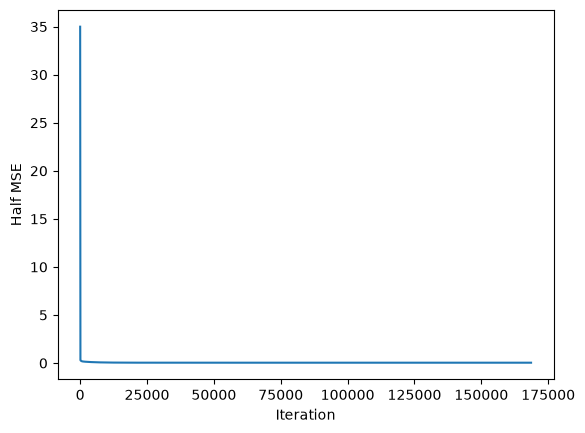

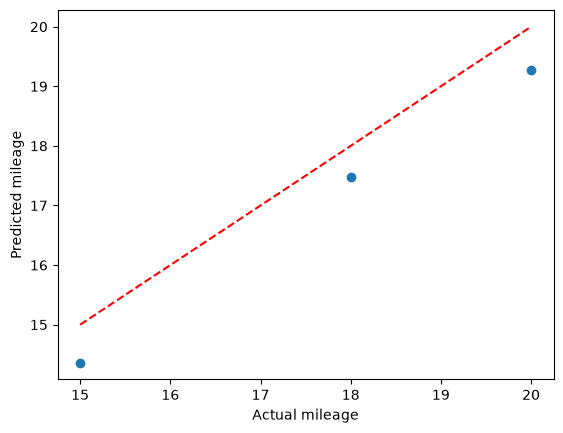

In [8]:
slopes = theta_ne[1:] / s
intercept = theta_ne[0] - slopes @ mu
print("Original intercept:", intercept)
print("Original slopes:", slopes)

import matplotlib.pyplot as plt
plt.plot(np.arange(len(cost)) * 100, cost)
plt.xlabel("Iteration")
plt.ylabel("Half MSE")
plt.show()
plt.scatter(y_test, Xte @ theta_ne)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual mileage")
plt.ylabel("Predicted mileage")
plt.show()
